# Logistic Regression & Maximum Likelihood Estimation

**Goal:** Predict a binary outcome (0 or 1) — e.g., pass/fail, spam/not spam.

Unlike linear regression which outputs any real number, logistic regression outputs a **probability** between 0 and 1.

---

## 1. The Sigmoid Function

The core of logistic regression is the **sigmoid** (logistic) function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

It squashes any real number $z$ into the range $(0, 1)$, making it interpretable as a probability.

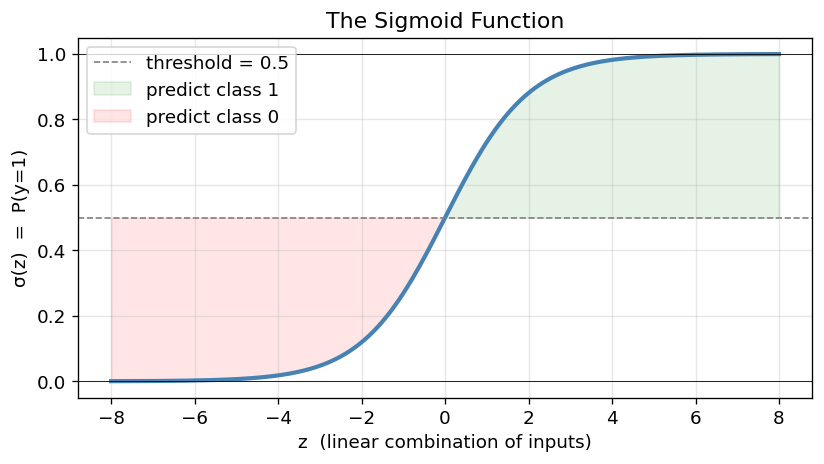

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# --- Sigmoid function ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, sigmoid(z), color='steelblue', lw=2.5)
ax.axhline(0.5, color='gray', lw=1, linestyle='--', label='threshold = 0.5')
ax.axhline(0,   color='black', lw=0.5)
ax.axhline(1,   color='black', lw=0.5)
ax.fill_between(z, sigmoid(z), 0.5, where=sigmoid(z) > 0.5, alpha=0.1, color='green', label='predict class 1')
ax.fill_between(z, sigmoid(z), 0.5, where=sigmoid(z) < 0.5, alpha=0.1, color='red',   label='predict class 0')
ax.set_xlabel('z  (linear combination of inputs)')
ax.set_ylabel('σ(z)  =  P(y=1)')
ax.set_title('The Sigmoid Function')
ax.legend(loc='upper left')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 2. The Model

Given a single feature $x$ (e.g., hours studied), logistic regression predicts:

$$\hat{y} = P(y=1 \mid x) = \sigma(w \cdot x + b) = \frac{1}{1 + e^{-(wx + b)}}$$

- $w$ = weight (slope), $b$ = bias (intercept)  
- The **decision boundary** is where $\hat{y} = 0.5$, i.e., $wx + b = 0$

### Interactive Explorer — drag the sliders to see how $w$ and $b$ shape the curve

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_model_interactive(w=1.0, b=0.0):
    x = np.linspace(-10, 10, 400)
    p = sigmoid(w * x + b)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, p, color='steelblue', lw=2.5, label=f'σ({w:.1f}·x + {b:.1f})')
    ax.axhline(0.5, color='gray', lw=1, linestyle='--')

    # decision boundary: wx + b = 0  →  x = -b/w
    if w != 0:
        boundary = -b / w
        if -10 <= boundary <= 10:
            ax.axvline(boundary, color='tomato', lw=2, linestyle='--',
                       label=f'boundary  x = {boundary:.2f}')
        ax.text(0.02, 0.95, f'boundary = -b/w = {boundary:.2f}',
                transform=ax.transAxes, fontsize=10, color='tomato',
                verticalalignment='top')

    # effect annotations
    direction = 'right' if w > 0 else 'left' if w < 0 else '—'
    ax.fill_between(x, p, 0.5, where=p > 0.5, alpha=0.08, color='green')
    ax.fill_between(x, p, 0.5, where=p < 0.5, alpha=0.08, color='red')

    ax.set_xlabel('x  (input feature)')
    ax.set_ylabel('P(y = 1 | x)')
    ax.set_title(f'Logistic curve:  w={w:.1f}  |  b={b:.1f}  |  slope direction: {direction}')
    ax.set_ylim(-0.05, 1.08)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    plot_model_interactive,
    w=widgets.FloatSlider(value=1.0, min=-5.0, max=5.0, step=0.1,
                          description='w (weight)', continuous_update=True,
                          style={'description_width': 'initial'}),
    b=widgets.FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.1,
                          description='b (bias)', continuous_update=True,
                          style={'description_width': 'initial'}),
)

interactive(children=(FloatSlider(value=1.0, description='w (weight)', max=5.0, min=-5.0, style=SliderStyle(de…

<function __main__.plot_model_interactive(w=1.0, b=0.0)>

---

## 3. Simple Dataset — Hours Studied vs. Pass/Fail

Let's build intuition with a toy 1D dataset.

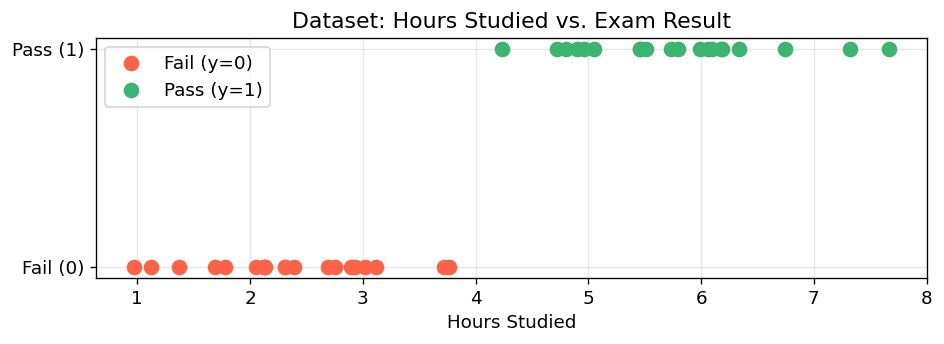

Sample size: 40  |  Fails: 20  |  Passes: 20


In [11]:
np.random.seed(42)

# Hours studied: class 0 (fail) centered at 2h, class 1 (pass) centered at 6h
X_fail = np.random.normal(loc=2.5, scale=0.8, size=20)
X_pass = np.random.normal(loc=6.0, scale=0.9, size=20)

X = np.concatenate([X_fail, X_pass])
y = np.concatenate([np.zeros(20), np.ones(20)])

fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(X_fail, np.zeros(20), color='tomato',    s=70, label='Fail (y=0)', zorder=3)
ax.scatter(X_pass, np.ones(20),  color='mediumseagreen', s=70, label='Pass (y=1)', zorder=3)
ax.set_xlabel('Hours Studied')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Fail (0)', 'Pass (1)'])
ax.set_title('Dataset: Hours Studied vs. Exam Result')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Sample size: {len(X)}  |  Fails: {int((y==0).sum())}  |  Passes: {int((y==1).sum())}")

---

## 4. Maximum Likelihood Estimation (MLE)

### Why not use mean squared error?

For classification, MSE has non-convex loss landscapes. Instead we use **Maximum Likelihood** — find parameters $(w, b)$ that make the observed data **most probable**.

### The Likelihood

For each sample, the model outputs a probability. Assuming samples are independent:

$$P(y=1 \mid x) = \hat{y}, \quad P(y=0 \mid x) = 1 - \hat{y}$$

We can write both cases compactly as:

$$P(y \mid x) = \hat{y}^{y} \cdot (1-\hat{y})^{1-y}$$

The **likelihood** over all $n$ samples:

$$\mathcal{L}(w, b) = \prod_{i=1}^{n} \hat{y}_i^{y_i} \cdot (1-\hat{y}_i)^{1-y_i}$$

### Log-Likelihood (easier to optimize)

Products → sums via logarithm (monotone transform, same maximum):

$$\log \mathcal{L}(w,b) = \sum_{i=1}^{n} \left[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \right]$$

We **maximize** the log-likelihood — equivalently **minimize** the **binary cross-entropy loss**:

$$\mathcal{J}(w,b) = -\frac{1}{n} \log \mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \right]$$

### Gradients for Gradient Descent

$$\frac{\partial \mathcal{J}}{\partial w} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)\, x_i, \qquad \frac{\partial \mathcal{J}}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$$

The update rule:

$$w \leftarrow w - \alpha \frac{\partial \mathcal{J}}{\partial w}, \qquad b \leftarrow b - \alpha \frac{\partial \mathcal{J}}{\partial b}$$

---

## 5. Visualizing the Loss Landscape

Before training, let's see how the loss changes as we vary $w$ (holding $b$ fixed at 0). This shows why we're looking for the minimum.

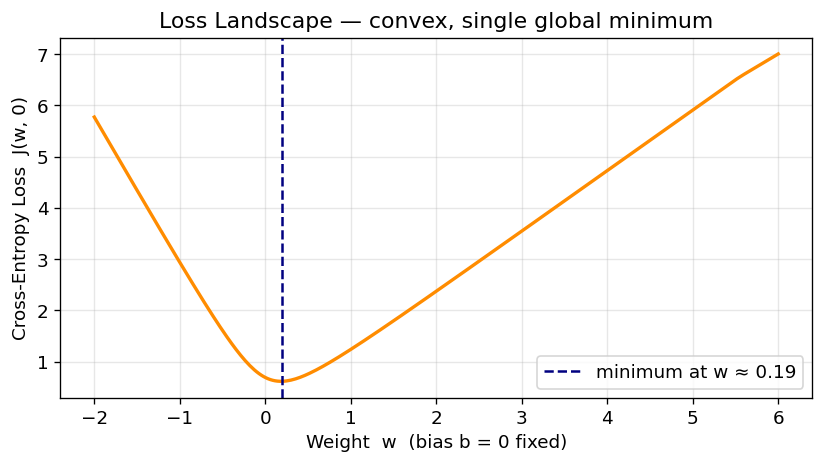

In [12]:
def binary_cross_entropy(X, y, w, b):
    y_hat = sigmoid(w * X + b)
    y_hat = np.clip(y_hat, 1e-9, 1 - 1e-9)  # numerical stability
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

w_range = np.linspace(-2, 6, 300)
losses  = [binary_cross_entropy(X, y, w, b=0) for w in w_range]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_range, losses, color='darkorange', lw=2)
ax.set_xlabel('Weight  w  (bias b = 0 fixed)')
ax.set_ylabel('Cross-Entropy Loss  J(w, 0)')
ax.set_title('Loss Landscape — convex, single global minimum')
ax.axvline(w_range[np.argmin(losses)], color='navy', linestyle='--',
           label=f'minimum at w ≈ {w_range[np.argmin(losses)]:.2f}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 6. Training with Gradient Descent

We implement the full training loop from scratch.

In [13]:
def train_logistic_regression(X, y, lr=0.1, n_iter=500):
    w, b = 0.0, 0.0
    loss_history = []

    for _ in range(n_iter):
        y_hat = sigmoid(w * X + b)
        y_hat = np.clip(y_hat, 1e-9, 1 - 1e-9)

        # gradients (derived from MLE / cross-entropy)
        dw = np.mean((y_hat - y) * X)
        db = np.mean(y_hat - y)

        w -= lr * dw
        b -= lr * db

        loss_history.append(binary_cross_entropy(X, y, w, b))

    return w, b, loss_history

w_fit, b_fit, loss_hist = train_logistic_regression(X, y, lr=0.1, n_iter=500)
print(f"Learned parameters:  w = {w_fit:.4f},  b = {b_fit:.4f}")
print(f"Decision boundary (x where P=0.5):  x = {-b_fit/w_fit:.3f} hours")
print(f"Final loss: {loss_hist[-1]:.4f}")

Learned parameters:  w = 1.1305,  b = -4.1916
Decision boundary (x where P=0.5):  x = 3.708 hours
Final loss: 0.1910


---

## 7. Results: Decision Boundary & Loss Curve

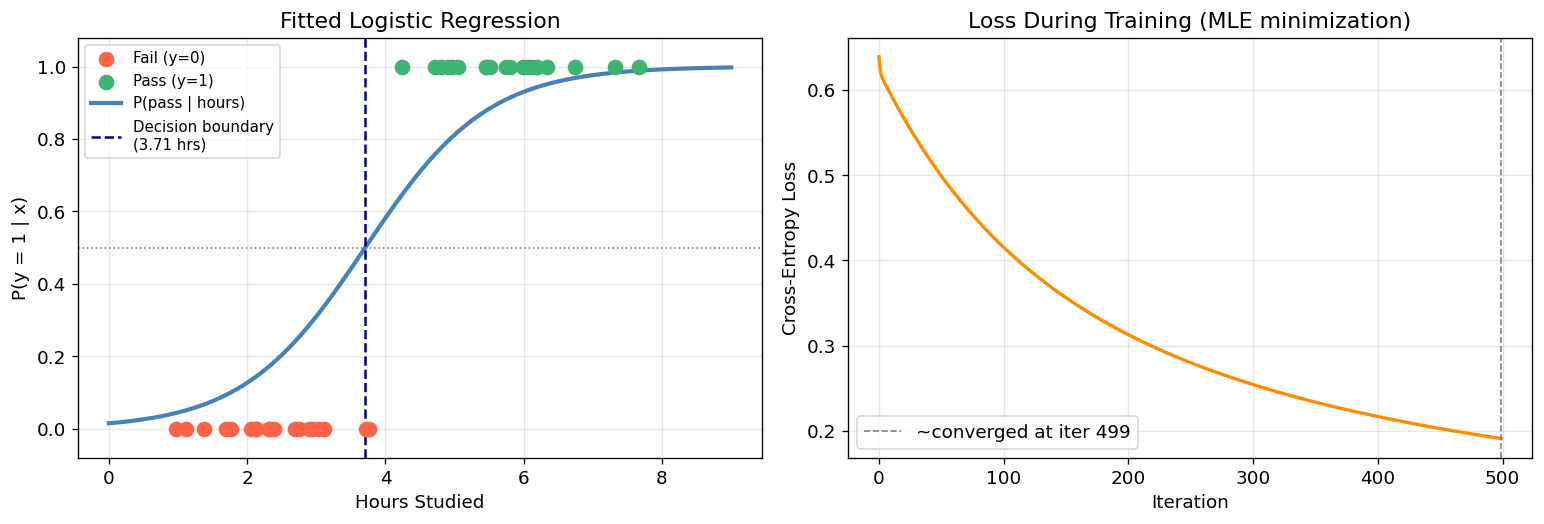

In [14]:
x_line = np.linspace(0, 9, 300)
p_line = sigmoid(w_fit * x_line + b_fit)
boundary = -b_fit / w_fit

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: fitted sigmoid over data ---
ax1.scatter(X_fail, np.zeros(20), color='tomato', s=70, zorder=4, label='Fail (y=0)')
ax1.scatter(X_pass, np.ones(20),  color='mediumseagreen', s=70, zorder=4, label='Pass (y=1)')
ax1.plot(x_line, p_line, color='steelblue', lw=2.5, label='P(pass | hours)')
ax1.axvline(boundary, color='navy', linestyle='--', lw=1.5,
            label=f'Decision boundary\n({boundary:.2f} hrs)')
ax1.axhline(0.5, color='gray', linestyle=':', lw=1)
ax1.set_xlabel('Hours Studied')
ax1.set_ylabel('P(y = 1 | x)')
ax1.set_title('Fitted Logistic Regression')
ax1.legend(fontsize=9)
ax1.set_ylim(-0.08, 1.08)
ax1.grid(alpha=0.3)

# --- Right: loss curve ---
ax2.plot(loss_hist, color='darkorange', lw=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Cross-Entropy Loss')
ax2.set_title('Loss During Training (MLE minimization)')
ax2.grid(alpha=0.3)

# annotate convergence
converged_iter = next(i for i, l in enumerate(loss_hist) if abs(l - loss_hist[-1]) < 1e-4)
ax2.axvline(converged_iter, color='gray', linestyle='--', lw=1,
            label=f'~converged at iter {converged_iter}')
ax2.legend()

plt.tight_layout()
plt.show()

---

## 8. Accuracy on Training Data

In [15]:
probs = sigmoid(w_fit * X + b_fit)
preds = (probs >= 0.5).astype(int)
accuracy = np.mean(preds == y)

print(f"Accuracy: {accuracy * 100:.1f}%")
print()
print("Sample predictions:")
print(f"{'Hours':>7}  {'True':>5}  {'P(pass)':>9}  {'Pred':>5}")
print("-" * 35)
idx = np.argsort(X)
for i in idx[::5]:
    print(f"{X[i]:7.2f}  {int(y[i]):>5}  {probs[i]:9.3f}  {preds[i]:>5}")

Accuracy: 95.0%

Sample predictions:
  Hours   True    P(pass)   Pred
-----------------------------------
   0.97      0      0.043      0
   2.05      0      0.133      0
   2.31      0      0.171      0
   2.93      0      0.294      0
   4.24      1      0.645      1
   5.05      1      0.820      1
   5.80      1      0.914      1
   6.19      1      0.943      1


---

## Summary

| Concept | Key Idea |
|---|---|
| **Sigmoid** | Maps $(-\infty, +\infty) \to (0, 1)$ — gives a probability |
| **Model** | $\hat{y} = \sigma(wx + b)$ |
| **MLE** | Find $w, b$ that maximize $P(\text{data} \mid w, b)$ |
| **Log-Likelihood** | Sum of log-probabilities — convex, easy to maximize |
| **Cross-Entropy Loss** | $-\log\mathcal{L}$ — what we minimize in practice |
| **Gradient Descent** | Iteratively move $w, b$ in the direction that reduces loss |

The beauty of MLE is that it gives us a principled reason to use cross-entropy: **maximizing the likelihood of the observed labels is exactly the same as minimizing the cross-entropy loss.**